# Amazon Sales & Inventory Analysis — Exploratory Data Analysis

This notebook picks up after the SQL cleaning pipeline (`sql/cleaning_data.sql`) and explores the cleaned data visually — distributions, category/size patterns, time trends, and the relationship between stock levels and sales demand.

## 1. Setup & Data Loading

Connects to the cleaned MySQL database and loads the `amazon_sales` and `inventory` tables. You'll be prompted for your MySQL password when this cell runs (not stored in the notebook).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [3]:
import getpass

user = 'root'
pas = quote_plus(getpass.getpass('Enter MySQL password: '))
host = 'localhost'
port = '3306'
database = 'inventory_analysis'

engine = create_engine(f"mysql+pymysql://{user}:{pas}@{host}:{port}/{database}")

ams = amazon_sales = pd.read_sql("select * from amazon_sales",engine)
inv = inventory =  pd.read_sql("select * from inventory",engine)

print("amazon",ams.shape)
print("inventory",inv.shape)

Enter MySQL password:  ········


amazon (128936, 22)
inventory (9203, 7)


## 2. Initial Data Overview & Null Value Investigation

Checking shape, dtypes, and missing values after loading the cleaned tables from MySQL, then investigating *why* `amount` is null for some rows (expected for cancelled orders; a smaller set of genuinely shipped orders with a null amount is flagged for follow-up).

In [5]:
ams.head(5)

,row_index,order_ID,order_date,Status,Fulfilment,sales_channel,ship_service_level,style,sku,category,...,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,unknown,0,INR,647.62,Mumbai,Maharashtra,400081,IN,0,Easy Ship\r
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,Shipped,1,INR,406.00,Bengaluru,Karnataka,560085,IN,0,Easy Ship\r
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,Shipped,1,INR,329.00,Navi Mumbai,Maharashtra,410210,IN,1,Amazon Fulfilled
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,unknown,0,INR,753.33,Puducherry,Puducherry,605008,IN,0,Easy Ship\r
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,Shipped,1,INR,574.00,Chennai,Tamil Nadu,600073,IN,0,Amazon Fulfilled


In [6]:
ams.shape

(128936, 22)

In [7]:
ams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128936 entries, 0 to 128935
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   row_index           128936 non-null  int64  
 1   order_ID            128936 non-null  object 
 2   order_date          128936 non-null  object 
 3   Status              128936 non-null  object 
 4   Fulfilment          128936 non-null  object 
 5   sales_channel       128936 non-null  object 
 6   ship_service_level  128936 non-null  object 
 7   style               128936 non-null  object 
 8   sku                 128936 non-null  object 
 9   category            128936 non-null  object 
 10  size                128936 non-null  object 
 11  asin                128936 non-null  object 
 12  courier_status      128936 non-null  object 
 13  qty                 128936 non-null  int64  
 14  currency            128936 non-null  object 
 15  amount              121146 non-nul

In [8]:
ams.isnull().sum()

row_index                0
order_ID                 0
order_date               0
Status                   0
Fulfilment               0
sales_channel            0
ship_service_level       0
style                    0
sku                      0
category                 0
size                     0
asin                     0
courier_status           0
qty                      0
currency                 0
amount                7790
ship_city                0
ship_state               0
ship_postal_code         0
ship_country             0
b2b                      0
fulfilled_by             0
dtype: int64

In [9]:
ams[ams['amount'].isnull()]['Status'].value_counts()

Status
Cancelled                       7561
Shipped                          208
Shipped - Delivered to Buyer       8
Shipping                           8
Shipped - Returned to Seller       3
Pending                            2
Name: count, dtype: int64

In [10]:
ams[ams['amount'].isnull()]['courier_status'].value_counts()

courier_status
Cancelled    5930
unknown      1736
Unshipped     124
Name: count, dtype: int64

In [11]:
ams[(ams['amount'].isnull()) & (ams['Status'] == 'Shipped')]

,row_index,order_ID,order_date,Status,Fulfilment,sales_channel,ship_service_level,style,sku,category,...,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by
937,937,S02-5278980-4327051,2022-04-30,Shipped,Amazon,Non-Amazon,Standard,BL017,BL017-63BLACK,Blouse,...,Unshipped,15,INR,NaN,Surat,Gujarat,394210,IN,0,Amazon Fulfilled
1057,1057,S02-9107114-0460608,2022-04-30,Shipped,Amazon,Non-Amazon,Standard,SET315,SET315-KR-PP-XL,Set,...,Unshipped,2,INR,NaN,Surat,Gujarat,394210,IN,0,Amazon Fulfilled
1615,1615,405-7790745-1369118,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,JNE3518,JNE3518-KR-M,kurta,...,Cancelled,0,INR,NaN,Rishikesh,Uttarakhand,249201,IN,0,Amazon Fulfilled
1987,1989,171-9673855-2321133,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,SET232,SET232-KR-PP-S,Set,...,Cancelled,0,INR,NaN,Dharuhera,Haryana,123106,IN,0,Amazon Fulfilled
2422,2424,404-7478762-7926753,2022-04-29,Shipped,Amazon,Amazon.in,Expedited,SET331,SET331-KR-NP-S,Set,...,Cancelled,0,INR,NaN,Gangapur City,Rajasthan,322201,IN,0,Amazon Fulfilled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124579,124616,S02-2059602-9568060,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,JNE3577,JNE3577-KR-S,kurta,...,Unshipped,1,INR,NaN,Surat,Gujarat,394210,IN,0,Amazon Fulfilled
124580,124617,S02-3811761-8377519,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,J0103,J0103-SKD-XS,Set,...,Unshipped,2,INR,NaN,Surat,Gujarat,394210,IN,0,Amazon Fulfilled
124582,124619,S02-5216693-3162561,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,SET154,SET154-KR-NP-XXL,Set,...,Unshipped,1,INR,NaN,Surat,Gujarat,394210,IN,0,Amazon Fulfilled
124584,124621,S02-7324586-1573702,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,SET097,SET097-KR-PP-XXXL,Set,...,Unshipped,1,INR,NaN,Surat,Gujarat,394210,IN,0,Amazon Fulfilled


## 3. Data Type Fixes & Final Cleanup

Trimming a leftover whitespace issue in inventory `color`, lowercasing column names for consistency, and setting correct dtypes (`b2b` as boolean, `order_date` as datetime).

In [13]:
inv['color'] = inv['color'].str.strip()

In [14]:
ams.columns = ams.columns.str.lower()
ams['b2b'] = ams['b2b'].astype(bool)
ams['order_date'] = pd.to_datetime(ams['order_date'])

## 4. Univariate Analysis

Distribution of order amounts, category- and size-level order volume, size-level stock-to-order ratio, and order status breakdown — all restricted to completed orders (Status indicates shipped/delivered AND courier_status confirms shipment) unless noted.

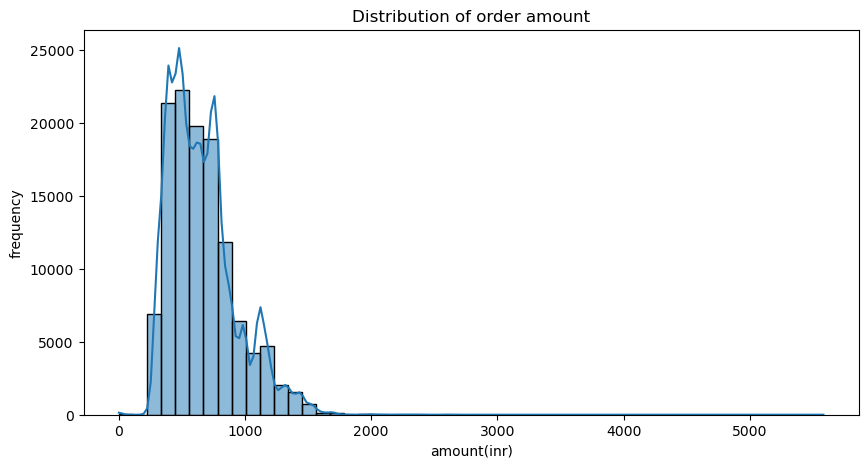

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(ams['amount'],bins=50,kde=True)
plt.title('Distribution of order amount')
plt.xlabel('amount(inr)')
plt.ylabel('frequency')
plt.show()

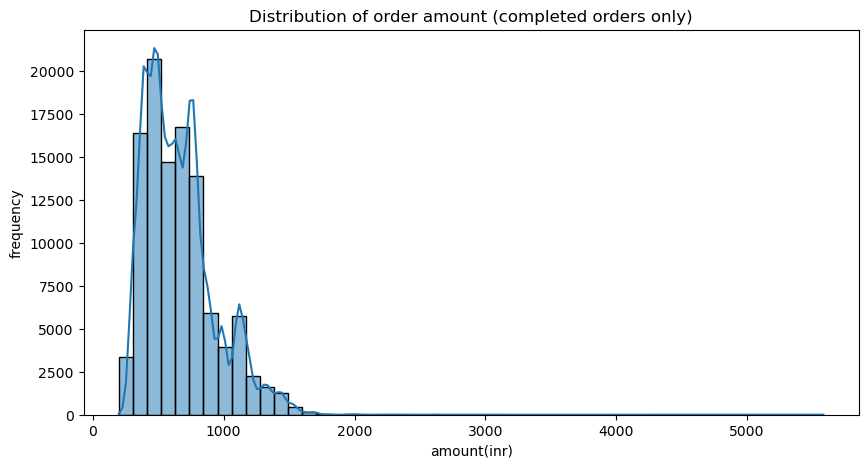

In [17]:
completed = ams[
    (ams['status'].isin(['Shipped - Delivered to Buyer', 'Shipped', 'Shipped - Out for Delivery', 'Shipped - Picked Up', 'Shipping'])) &
    (ams['courier_status'] == 'Shipped')
]

plt.figure(figsize=(10,5))
sns.histplot(completed['amount'],bins=50,kde=True)
plt.title('Distribution of order amount (completed orders only)')
plt.xlabel('amount(inr)')
plt.ylabel('frequency')
plt.show()

In [18]:
ams[ams['amount'] > 2000][
    (ams['status'].isin(['Shipped - Delivered to Buyer', 'Shipped', 'Shipped - Out for Delivery', 'Shipped - Picked Up', 'Shipping'])) &
    (ams['courier_status'] == 'Shipped')
][['sku', 'category', 'qty', 'amount']].sort_values('amount', ascending=False).head(20)

C:\Users\ARA LIFE\AppData\Local\Temp\ipykernel_25176\3940395327.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ams[ams['amount'] > 2000][


,sku,category,qty,amount
42024,SET268-KR-NP-XS,Set,8,5584.0
11157,J0013-SKD-XXXL,Set,5,5495.0
89120,SET197-KR-NP-M,Set,4,3036.0
121192,SET278-KR-NP-XXXL,Set,2,2894.0
28804,J0285-SKD-S,Set,2,2864.0
39930,JNE3797-KR-XS,Western Dress,4,2860.0
63957,J0230-SKD-XL,Set,2,2698.0
120986,SET374-KR-NP-XXL,Set,4,2664.0
54590,J0341-DR-XXL,Western Dress,3,2655.0
67747,J0238-LCD-XL,Set,1,2598.0


In [19]:
ams[(ams['sku']=='SET397-KR-NP -M') & (ams['amount']>2000)]

,row_index,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,...,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by
24485,24494,407-3483041-9133135,2022-04-16,Cancelled,Merchant,Amazon.in,Standard,SET397,SET397-KR-NP -M,Set,...,unknown,0,INR,4235.72,Jaipur,Rajasthan,302012,IN,False,Easy Ship\r


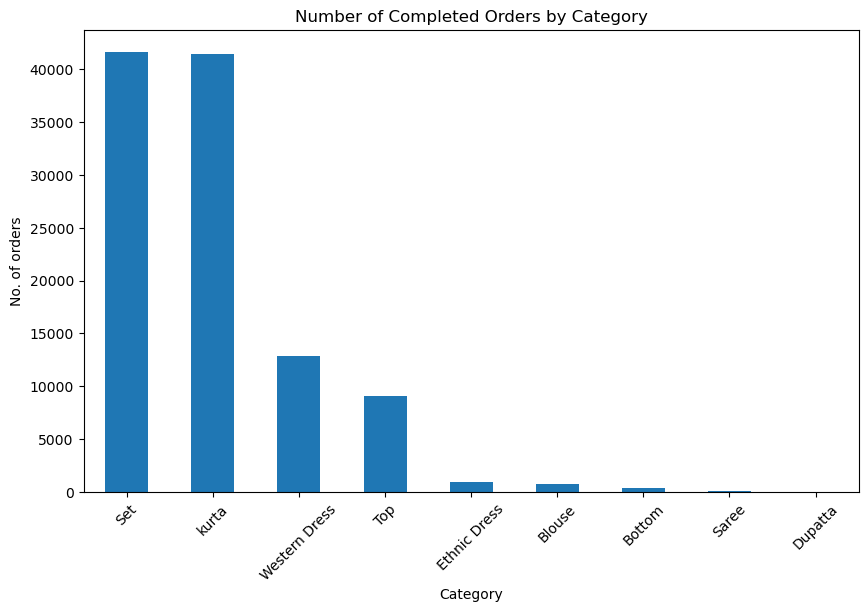

In [20]:
plt.figure(figsize=(10,6))
completed['category'].value_counts().plot(kind='bar')
plt.title('Number of Completed Orders by Category')
plt.xlabel('Category')
plt.ylabel('No. of orders')
plt.xticks(rotation=45)
plt.show()

In [21]:
completed.groupby('category')['amount'].sum().sort_values(ascending=False)

category
Set              35587754.76
kurta            19325835.25
Western Dress     9995047.14
Top               4884569.09
Ethnic Dress       738371.46
Blouse             422911.77
Bottom             136354.34
Saree              114492.80
Dupatta               915.00
Name: amount, dtype: float64

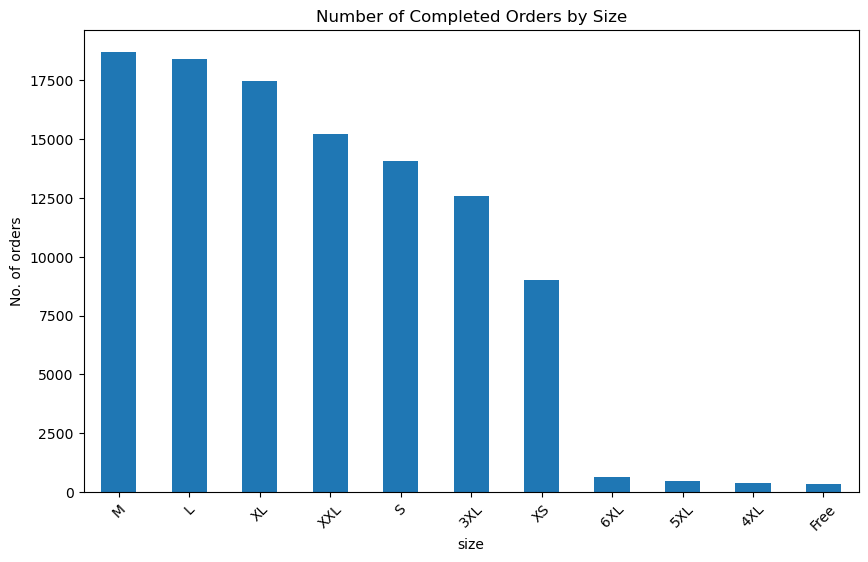

In [22]:
plt.figure(figsize=(10,6))
completed['size'].value_counts().plot(kind='bar')
plt.title('Number of Completed Orders by Size')
plt.xlabel('size')
plt.ylabel('No. of orders')
plt.xticks(rotation=45)
plt.show()

In [23]:
mapping = {'XXXL' : '3XL', 'FREE':'Free'}

inv['size']=inv['size'].replace(mapping)

In [24]:
print("Sizes in sales data:", sorted(completed['size'].unique()))
print("Sizes in inventory data:", sorted(inv['size'].unique()))

Sizes in sales data: ['3XL', '4XL', '5XL', '6XL', 'Free', 'L', 'M', 'S', 'XL', 'XS', 'XXL']
Sizes in inventory data: ['3XL', '4XL', '5XL', '6XL', 'Free', 'L', 'M', 'S', 'XL', 'XS', 'XXL']


In [25]:
size_demanded = completed['size'].value_counts()
size_stock = inv.groupby('size')['stock'].sum()

comparison = pd.DataFrame({'orders':size_demanded,'stock':size_stock}).sort_values('orders',ascending=False)
comparison

,orders,stock
size,,
M,18706,37163
L,18423,32953
XL,17474,32046
XXL,15236,30683
S,14059,41872
3XL,12595,21596
XS,9025,35082
6XL,653,962
5XL,478,901


In [26]:
inv.groupby('size')['stock'].sum()

size
3XL     21596
4XL       955
5XL       901
6XL       962
Free     7840
L       32953
M       37163
S       41872
XL      32046
XS      35082
XXL     30683
Name: stock, dtype: int64

In [27]:
comparison['sto_ratio']= round(comparison['stock']/comparison['orders'],2)
print(comparison.sort_values('sto_ratio',ascending=False))

      orders  stock  sto_ratio
size                          
Free     320   7840      24.50
XS      9025  35082       3.89
S      14059  41872       2.98
4XL      370    955       2.58
XXL    15236  30683       2.01
M      18706  37163       1.99
5XL      478    901       1.88
XL     17474  32046       1.83
L      18423  32953       1.79
3XL    12595  21596       1.71
6XL      653    962       1.47


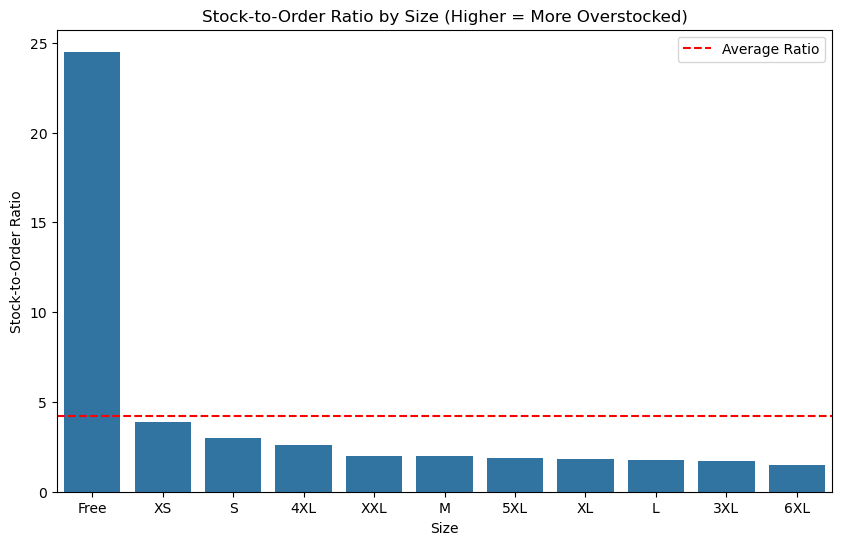

In [28]:
plt.figure(figsize=(10,6))
comparison_sorted = comparison.sort_values('sto_ratio', ascending=False)
sns.barplot(x=comparison_sorted.index, y=comparison_sorted['sto_ratio'])
plt.title('Stock-to-Order Ratio by Size (Higher = More Overstocked)')
plt.xlabel('Size')
plt.ylabel('Stock-to-Order Ratio')
plt.axhline(y=comparison['sto_ratio'].mean(), color='r', linestyle='--', label='Average Ratio')
plt.legend()
plt.show()

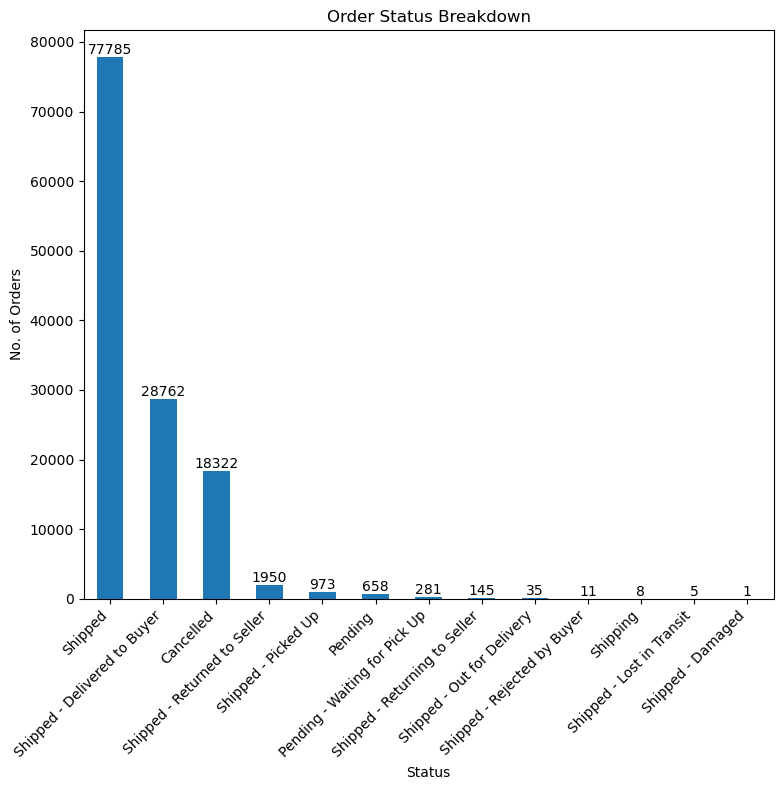

In [29]:
plt.figure(figsize=(8,8))
la = ams['status'].value_counts().plot(kind='bar')
plt.title('Order Status Breakdown')
plt.ylabel('No. of Orders')
plt.xlabel('Status')
plt.xticks(rotation=45,ha='right')
for i in la.containers:
    la.bar_label(i)
plt.tight_layout()
plt.show()

## 5. Time-Based Analysis

Monthly revenue trend (excluding the partial-March data — the dataset contains only a single day of March records), order volume vs. average order value by month, and day-of-week ordering patterns.

In [31]:
completed['order_date'] = pd.to_datetime(completed['order_date'])

C:\Users\ARA LIFE\AppData\Local\Temp\ipykernel_25176\3363661586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed['order_date'] = pd.to_datetime(completed['order_date'])


In [32]:
completed.dtypes

row_index                      int64
order_id                      object
order_date            datetime64[ns]
status                        object
fulfilment                    object
sales_channel                 object
ship_service_level            object
style                         object
sku                           object
category                      object
size                          object
asin                          object
courier_status                object
qty                            int64
currency                      object
amount                       float64
ship_city                     object
ship_state                    object
ship_postal_code              object
ship_country                  object
b2b                             bool
fulfilled_by                  object
dtype: object

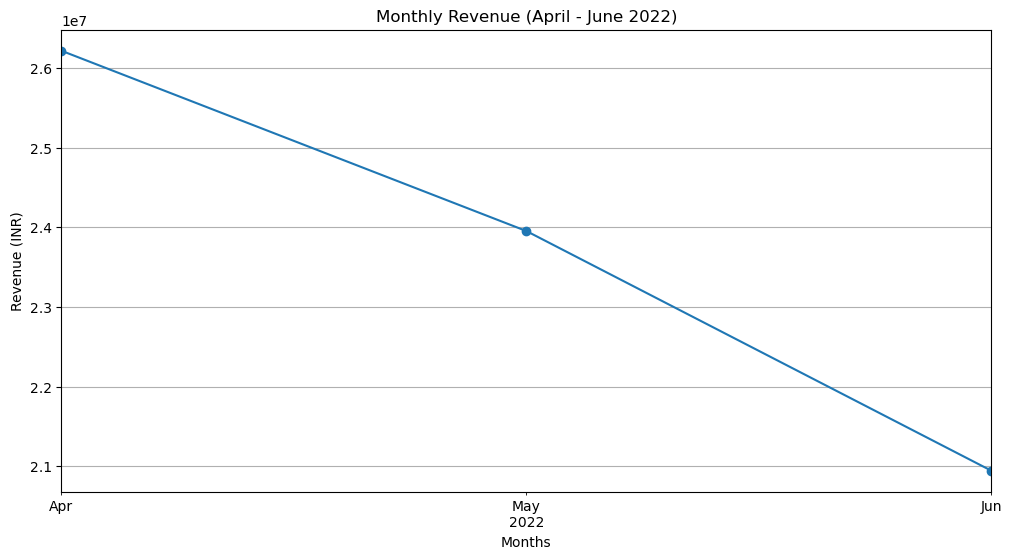

In [33]:
monthly_c = completed[completed['order_date']>='2022-04-01']    #march has only 1 date
monthly_revenue = monthly_c.groupby(monthly_c['order_date'].dt.to_period('M'))['amount'].sum()
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line' , marker='o')
plt.title('Monthly Revenue (April - June 2022)')
plt.xlabel('Months')
plt.ylabel('Revenue (INR)')
plt.grid(True)
plt.show()

In [34]:
ams[ams['order_date'].dt.to_period('M') == '2022-03']['order_date'].describe()

count                    171
mean     2022-03-31 00:00:00
min      2022-03-31 00:00:00
25%      2022-03-31 00:00:00
50%      2022-03-31 00:00:00
75%      2022-03-31 00:00:00
max      2022-03-31 00:00:00
Name: order_date, dtype: object

In [35]:
# Did cancellation rates increase over these months? (could explain declining completed revenue)
monthly_c.groupby(monthly_c['order_date'].dt.to_period('M'))['status'].apply(
    lambda x: (x == 'Cancelled').sum() / len(x) * 100
)

order_date
2022-04    0.0
2022-05    0.0
2022-06    0.0
Freq: M, Name: status, dtype: float64

In [36]:
monthly_c.groupby(monthly_c['order_date'].dt.to_period('M')).agg(total_orders=('order_date','count'),avg_order=('amount','mean'))

,total_orders,avg_order
order_date,,
2022-04,40927,640.550474
2022-05,35355,677.486608
2022-06,30906,677.658718


In [37]:
monthly_c.groupby(monthly_c['order_date'].dt.to_period('M')).agg(total_orders=('order_date','count'),avg_order=('amount','sum'))

,total_orders,avg_order
order_date,,
2022-04,40927,26215809.23
2022-05,35355,23952539.04
2022-06,30906,20943720.34


C:\Users\ARA LIFE\AppData\Local\Temp\ipykernel_25176\4262459271.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed['weekday'] = completed['order_date'].dt.day_name()


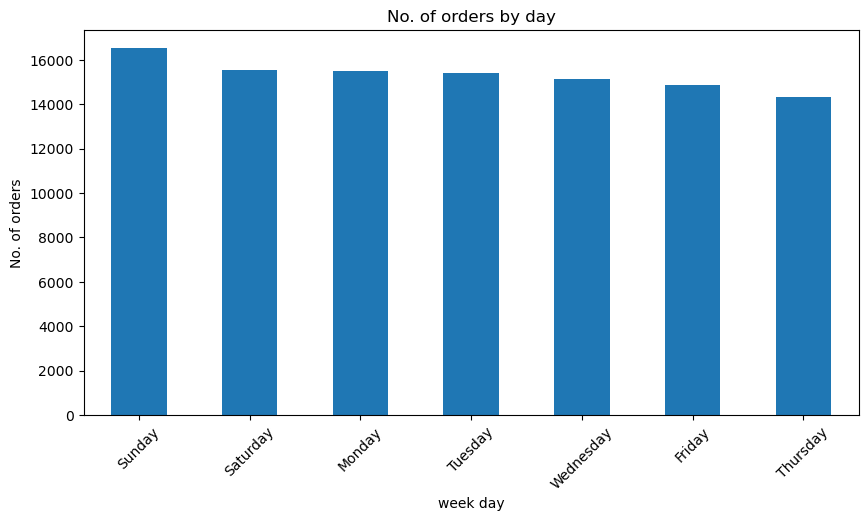

In [38]:
completed['weekday'] = completed['order_date'].dt.day_name()
order_weekday = completed['weekday'].value_counts()

plt.figure(figsize=(10,5))
order_weekday.plot(kind='bar')
plt.title('No. of orders by day')
plt.xlabel('week day')
plt.ylabel('No. of orders')
plt.xticks(rotation=45)
plt.show()

## 6. Relationship Analysis: Stock vs. Sales

Merging sales and inventory at the SKU level to examine the relationship between current stock and units sold, calculate a stock-to-sales ratio per SKU, and identify the highest-priority restock candidates (high demand, low/zero remaining stock).

In [103]:
sku_sales = completed.groupby(completed['sku']).agg(unit_sold = ('qty','sum'), total_amount = ('amount','sum')).reset_index()

sku_merged = sku_sales.merge(inv, left_on='sku', right_on='sku_code',how='inner')

print(sku_merged.shape)
sku_merged.head(5)

(6522, 10)


,sku,unit_sold,total_amount,row_index,sku_code,design_no,stock,category,size,color
0,AN201-RED-M,2,458.0,1,AN201-RED-M,AN201,5,LEGGINGS,M,Red
1,AN201-RED-XL,2,602.0,3,AN201-RED-XL,AN201,6,LEGGINGS,XL,Red
2,AN201-RED-XXL,1,229.0,4,AN201-RED-XXL,AN201,3,LEGGINGS,XXL,Red
3,AN202-ORANGE-M,2,530.0,6,AN202-ORANGE-M,AN202,3,LEGGINGS,M,Orange
4,AN202-ORANGE-S,4,1141.0,7,AN202-ORANGE-S,AN202,16,LEGGINGS,S,Orange


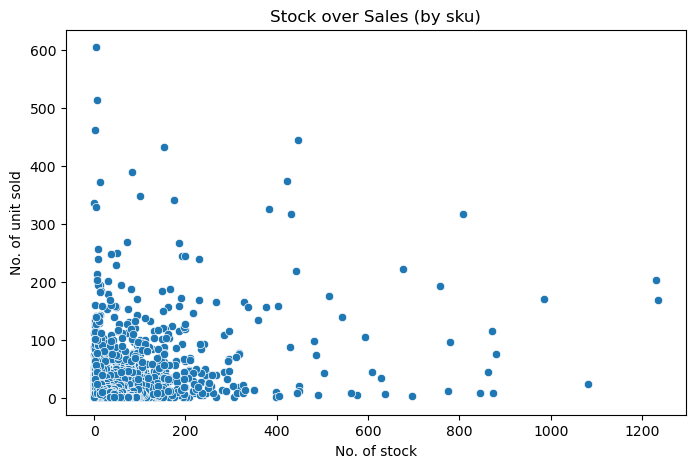

In [105]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=sku_merged,x='stock',y='unit_sold')
plt.title('Stock over Sales (by sku)')
plt.xlabel('No. of stock')
plt.ylabel('No. of unit sold')
plt.show()

In [107]:
correlation = sku_merged['stock'].corr(sku_merged['unit_sold'])
print(correlation)

0.30076155411074507


In [109]:
print(f"Correlation between stock and units sold: {correlation:.3f}")

Correlation between stock and units sold: 0.301


In [111]:
sku_merged['sts_ratio'] = round(sku_merged['stock']/sku_merged['unit_sold'],2)

In [113]:
sku_merged.sort_values('sts_ratio').head(10)

,sku,unit_sold,total_amount,row_index,sku_code,design_no,stock,category,size,color,sts_ratio
4003,JNE3783-KR-S,7,3426.00,5981,JNE3783-KR-S,JNE3783,0,KURTA,S,Brown,0.0
3113,JNE3581-KR-L,4,2540.00,4883,JNE3581-KR-L,JNE3581,0,KURTA,L,Pink,0.0
2690,JNE3461-KR-XXXL,49,18875.00,4262,JNE3461-KR-XXXL,JNE3461,0,KURTA,3XL,Teal,0.0
4007,JNE3783-KR-XXXL,19,9483.00,5985,JNE3783-KR-XXXL,JNE3783,0,KURTA,3XL,Brown,0.0
6189,SET361-KR-NP-L,1,1168.90,8843,SET361-KR-NP-L,SET361,0,SET,L,White,0.0
4006,JNE3783-KR-XXL,10,5020.00,5984,JNE3783-KR-XXL,JNE3783,0,KURTA,XXL,Brown,0.0
6193,SET363-KR-NP-L,39,48633.00,8850,SET363-KR-NP-L,SET363,0,SET,L,Pink,0.0
6194,SET363-KR-NP-M,31,38749.00,8851,SET363-KR-NP-M,SET363,0,SET,M,Pink,0.0
5606,SET260-KR-PP-S,6,3374.00,8217,SET260-KR-PP-S,SET260,0,KURTA SET,S,Grey,0.0
4005,JNE3783-KR-XS,1,492.03,5983,JNE3783-KR-XS,JNE3783,0,KURTA,XS,Brown,0.0


In [115]:
(sku_merged['unit_sold']).isnull().sum()

0

In [117]:
sku_merged.sort_values(['sts_ratio', 'unit_sold'], ascending=[True, False]).head(10)

,sku,unit_sold,total_amount,row_index,sku_code,design_no,stock,category,size,color,sts_ratio
4100,JNE3797-KR-S,463,346664.88,6079,JNE3797-KR-S,JNE3797,2,KURTA,S,Green,0.0
4103,JNE3797-KR-XXL,336,248787.40,6082,JNE3797-KR-XXL,JNE3797,0,KURTA,XXL,Green,0.0
2855,JNE3510-KR-M,111,50556.38,4502,JNE3510-KR-M,JNE3510,0,KURTA,M,Grey,0.0
4124,JNE3800-KR-XXL,87,65379.49,6103,JNE3800-KR-XXL,JNE3800,0,KURTA,XXL,Mustard,0.0
598,J0095-SET-XXL,74,47708.62,1101,J0095-SET-XXL,J0095,0,KURTA SET,XXL,Blue,0.0
4313,JNE3861-DR-L,53,44023.26,6427,JNE3861-DR-L,JNE3861,0,DRESS,L,Red,0.0
2690,JNE3461-KR-XXXL,49,18875.00,4262,JNE3461-KR-XXXL,JNE3461,0,KURTA,3XL,Teal,0.0
4031,JNE3787-KR-S,41,19841.95,6009,JNE3787-KR-S,JNE3787,0,KURTA,S,Blue,0.0
6193,SET363-KR-NP-L,39,48633.00,8850,SET363-KR-NP-L,SET363,0,SET,L,Pink,0.0
5736,SET282-KR-PP-XXXL,34,35905.03,8369,SET282-KR-PP-XXXL,SET282,0,KURTA SET,3XL,Yellow,0.0


In [119]:
style_summary = sku_merged.groupby(sku_merged['sku'].str.split('-').str[0]).agg(
    total_units_sold=('unit_sold', 'sum'),
    total_revenue=('total_amount', 'sum'),
    total_stock=('stock', 'sum')
).sort_values('total_stock')

style_summary.head(10)

,total_units_sold,total_revenue,total_stock
sku,,,
SAR034,1,772.00,0
SET036,1,383.00,0
SET072,1,370.00,0
J0027,7,4264.00,0
SET121,5,2427.00,0
JNE3783,64,31982.03,0
SET260,6,3374.00,0
SAR066,3,2053.00,0
J0182,1,699.00,0


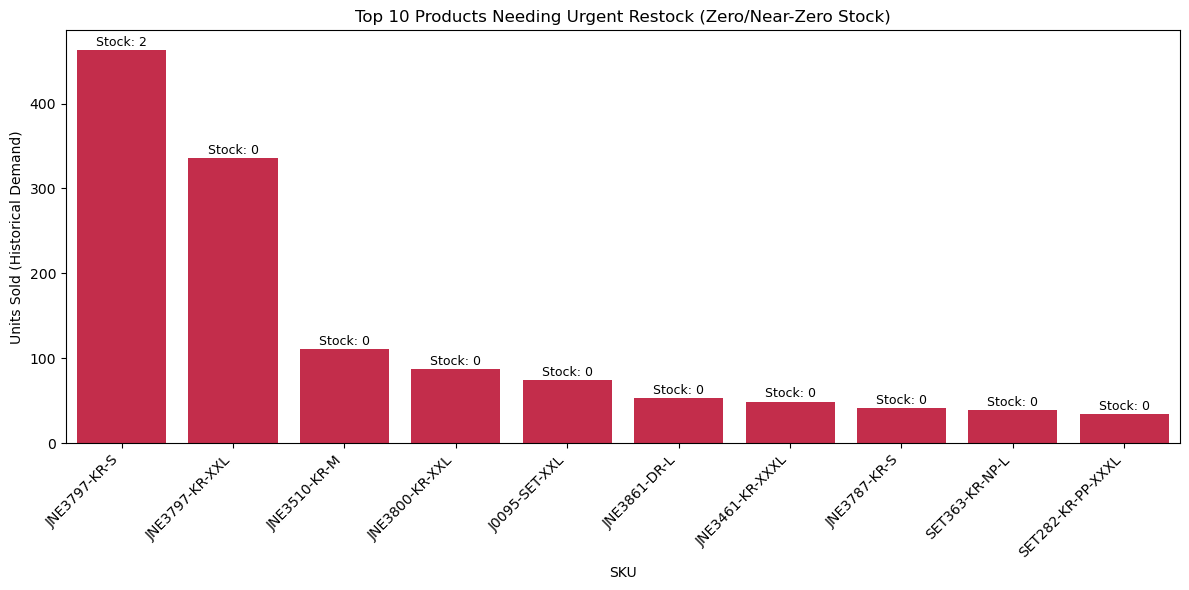

In [121]:
top10_urgent = sku_merged.sort_values(['sts_ratio', 'unit_sold'], ascending=[True, False]).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top10_urgent, x='sku', y='unit_sold', color='crimson')
plt.title('Top 10 Products Needing Urgent Restock (Zero/Near-Zero Stock)')
plt.xlabel('SKU')
plt.ylabel('Units Sold (Historical Demand)')
plt.xticks(rotation=45, ha='right')

# Add stock count as a label on each bar, to show HOW depleted each one is
for i, row in enumerate(top10_urgent.itertuples()):
    plt.text(i, row.unit_sold + 5, f"Stock: {row.stock}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

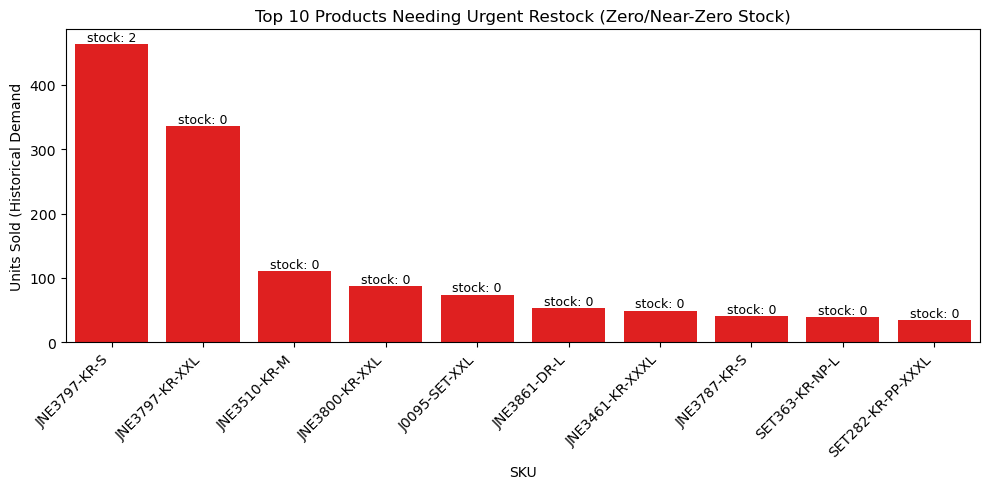

In [123]:
top_10u = sku_merged.sort_values(['sts_ratio','unit_sold'],ascending=[True,False]).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_10u , x = 'sku', y = 'unit_sold', color='r')
plt.title('Top 10 Products Needing Urgent Restock (Zero/Near-Zero Stock)')
plt.xlabel('SKU')
plt.ylabel('Units Sold (Historical Demand')
plt.xticks(rotation=45, ha='right')
for i,j in enumerate(top_10u.itertuples()):
    plt.text(i,j.unit_sold+5,f'stock: {j.stock}',fontsize=9, ha='center')
    
    
plt.tight_layout()
plt.show()

## 7. Outlier Detection

Box plots of order amount overall and by category, to identify unusually high-value orders and check whether outliers are concentrated in specific categories.

Text(0.5, 0, 'amount(INR)')

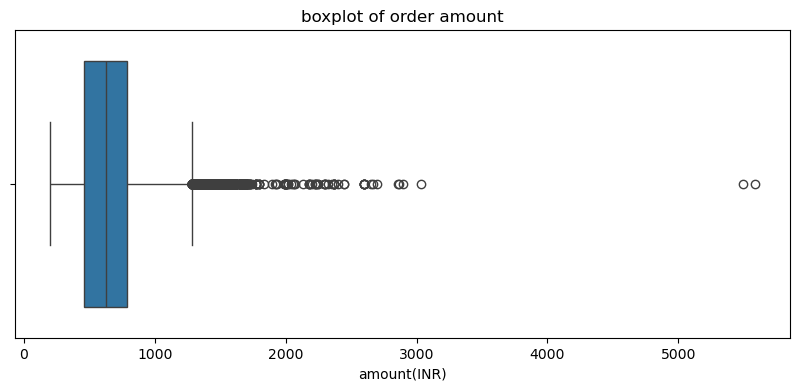

In [125]:
plt.figure(figsize=(10,4))
sns.boxplot(x=completed['amount'])
plt.title('boxplot of order amount')
plt.xlabel('amount(INR)')

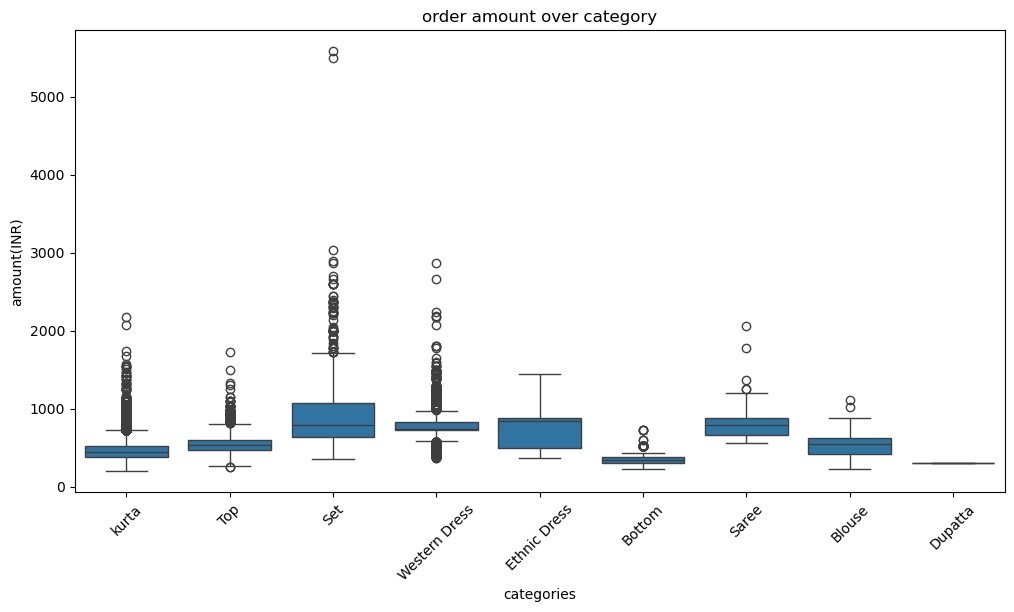

In [127]:
plt.figure(figsize=(12,6))
sns.boxplot(data=completed, x = 'category',y='amount')
plt.title('order amount over category')
plt.xlabel('categories')
plt.ylabel('amount(INR)')
plt.xticks(rotation=45)
plt.show()

In [54]:
inv['category'] = inv['category'].str.replace('AN : LEGGINGS','LEGGINGS')